# Glagoljski rukopisi Zadarske nadbiskupije – vizualizacije

**Izvor podataka:** [GlagoLab / Centar za istraživanje glagoljaštva](https://glagolab.unizd.hr)  
**Zbirka:** Glagoljski kodeksi Zadarske nadbiskupije (prikupio don Pavao Kero)  
**Sadržaj:** Interaktivne karte, grafovi i oblak riječi na temelju metapodataka iz kataloga.  

> Pokrenite sve ćelije redom: **Runtime → Run all** (Google Colab) ili **Cell → Run All** (Jupyter).

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  POSTAVLJANJE OKRUŽENJA — pokrenite ovu ćeliju PRVU                     ║
# ║  (automatski instalira pakete koji nedostaju u Google Colabu)           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import subprocess, sys, os

REQUIRED = ['folium', 'wordcloud', 'geopy', 'altair']
installed = {pkg.split('==')[0].lower() for pkg in
             subprocess.run([sys.executable, '-m', 'pip', 'list', '--format=freeze'],
                            capture_output=True, text=True).stdout.splitlines()}
missing = [p for p in REQUIRED if p.lower() not in installed]
if missing:
    print(f'Instaliram: {missing}')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print('Paketi instalirani.')
else:
    print('Svi potrebni paketi su već instalirani.')

os.makedirs('slike', exist_ok=True)
print('Mapa slike/ je spremna.')

Svi potrebni paketi su već instalirani.
Mapa slike/ je spremna.


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
import os
from collections import Counter
from IPython.display import display, HTML

import folium
from folium.plugins import MarkerCluster, HeatMap

import altair as alt
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PALETTE = [
    '#2E4057', '#048A81', '#54C6EB', '#EEB902', '#EF6F6C',
    '#6B4226', '#A8D5BA', '#C97B84', '#5B5EA6', '#E8A838',
    '#3D9970', '#FF4136', '#7FDBFF', '#B10DC9', '#01FF70'
]
print('Paketi uspješno učitani.')

Paketi uspješno učitani.


In [3]:
# ── Učitavanje podataka ───────────────────────────────────────────────────────
# Podaci su ugrađeni izravno – nije potrebna eksterna datoteka.
import pandas as pd
import numpy as np

COLS = ['id', 'naslov', 'raspon_godina_izdavanja_proizvodnje', 'mjesto_izdavanja_proizvodnje', 'materijal_podloge', 'sadrzi_vodeni_znak', 'vodeni_znak', 'materijal_uveza', 'vrsta_uveza', 'ocuvanost_primjerka_uvez', 'ocuvanost_primjerka_knjizni_blok', 'organizacija', 'provenijencija', 'imatelj', 'signatura', 'sadrzaj']

RAW_ROWS = [
    (13487, "Starinski godovi mrtvih od Kali", "1680. - 1873.", "Kali", "a – papir, općenito", "Tri polumjeseca", "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13524, "Madrikula Bratovštine svetog Sakramenta", "1675 -", "Kali", "a – papir, općenito", "Kruna, zvijezda i mjesec;Slova M i P s trolistom", "1 – papir sadrži vodeni znak", "f – karton", "b – preuvezano", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u Župama Zadarske nadbiskupije", "Doneseno iz Župnog ureda Kali u Arhiv zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13572, "Madrikula Bratovštine svetog Križa", "1717. - 1807. i 1857.", "Kali", "a – papir, općenito", "Tri polumjeseca", None, "b – koža;f – karton", "a – izvorni, tj. prvi", "d – oštećen", "d – oštećen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13574, "Madrikula bratovština svetog Sakramenta i svetog Križa (fragmenti)", None, None, "a – papir, općenito", None, "0 – papir ne sadrži vodeni znak", "f – karton", "b – preuvezano", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u Župama Zadarske nadbiskupije", "Doneseno iz Župnog ureda Kali u Arhiv zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj je vrlo zanimljiv za Bratovštinu, crkvu i selo."),
    (13604, "Madrikula Bratovštine Gospe Sedam žalosti", "1729. - 1807., 1858. - 1966.", "Kali", "a – papir, općenito", "Slova F i S s trolistom;Ptica na planinama u krugu", "1 – papir sadrži vodeni znak", "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 17 kapitula, popis braće, gozbe, dražbe."),
    (13641, "Madrikula Bratovštine svetog Trojstva", "1683. - 1807. i 1857.", "Kali", "a – papir, općenito", "Slovo Z;Kruna, zvijezda i mjesec", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 15 kapitula, popis bratima i rad Bratovštine."),
    (13642, "Madrikula Bratovštine Gospe od Luzarija", "1619. - 1733.", "Kali", "a – papir, općenito", "Slova T i B s trolistom", "1 – papir sadrži vodeni znak", "b – koža", "k – restaurirani originalni uvez", "b – dobro očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 28 kapitula (str. 1-6), koji odišu starinom kao i jezik; popis braće svećenika i svjetovnjaka (str. 7-10, 13-18); rad bratovština Sv. Skramenta i Sv. Lovre te crkveni računi. Vrlo su zanimljivi podatci o bratovštinama, o župnoj crkvi i seoskim društvenim odnosima."),
    (13650, "Govorenje od posluha", "18. st.", "Sali", "a – papir, općenito", "Tri polumjeseca;Slovo C", "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "e – oštećen hrbat", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13653, "Madrikula Braće zmorašnjeg kraja", "1658. - 1791.", "Sali", "a – papir, općenito", "Tri mjeseca;Dva broja 8", "1 – papir sadrži vodeni znak", "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13669, "Madrikula laičko - svećeničke Bratovštine svetog Karla Boromejskoga", "1640. - 1814.", "Sali", "a – papir, općenito", "Tri mjeseca;Trolist sa slovima S i S", "1 – papir sadrži vodeni znak", "d – platno", "a – izvorni, tj. prvi", "b – dobro očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sali u Arhiv Zadarske nadbiskupije. Na stranici 24v nalazi se pečat nadbiskupa Vicka Zmajevića.", "Arhiv Zadarske nadbiskupije", None, None),
    (13677, "Namirnice za izgovorene mise", None, "Sali", "a – papir, općenito", "Inicijali G, B i F s ornamentom;Ptica;Ornamenti;Slova G i D;Slova I i F s polumjesecom;Slova F i V;Ptica s natpisom ROSA;Slova M i C u srcu;Grb", "1 – papir sadrži vodeni znak", "z – drugo", None, "f – nedostaje uvez", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Kodeks je nekoć pripadao obitelji Petricioli, a danas je vlasništvo Župnog ureda u Salima. Sada u Arhivu Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: evidencija o izgovorenim i podmirenim misama za razdoblje od 1785. do 1800. godine. Za neke godine podatci nedostaju. Na prednjoj korici zapis talijanskim jezikom: \"Carte scritte in Illirico relative alla chiesa Parrochiale di Sale.\""),
    (13686, "Libar lašov crkve svete Marije", None, "Sali", "a – papir, općenito", "Sunce;Trolist sa slovom A i brojem 3", "1 – papir sadrži vodeni znak", "b – koža", "e – restauriran, imitacija", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Vlasništvo Župnog ureda u Salima. Sada u Arhivu Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Prva je bilješka iz 1658. godine. Sadržaj: popis laši, tj. ostavština župniku i kapelanu Župe Sv. Marije u Salima i to u kućama, najmovima, maslinama, vinogradima; različite zamjene zemalja i sl. Pri kraju su prijepisi 26 oporuka."),
    (13690, "Madrikula Bratovštine Gospe Ruzarija", "XVII. - XIX. st.", "Sali", "a – papir, općenito", "Tri mjeseca;Trolist sa slovima A i C", "1 – papir sadrži vodeni znak", "b – koža", "e – restauriran, imitacija", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13692, "Matična knjiga krizmanih", "1698. - 1825.", "Sali", "a – papir, općenito", "Tri mjeseca;Slovo Z", "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13696, "Knjiga Stanje duša, 1695. – 1825.", "1695. – 1825.", "Sali", "a – papir, općenito", "Tri polumjeseca;Slova G, M i Z s križem", "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na str. 76 je zabilježeno da godine 1844. Sali imaju 555 duša."),
    (13705, "Libar braće svete Marije", None, "Sali", "a – papir, općenito", "Bik;Sidro sa zvijezdom;Slovo U", "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "a – odlično očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13736, "Madrikula Bratovštine svetoga Sakramenta", "1753. ‒ 1862.", "Žman", "a – papir, općenito", "Tri polumjeseca sa slovom Z", "1 – papir sadrži vodeni znak", "f – karton", "l – restaurirani neoriginalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na str. 2, godine 1829. piše: \"Madrikula od Xmana skulle Suetogha Sakarmenta i Brašchine o Xmana sluxechi po redu jedan za drugim koi bude umiti vladati što ima Carkva S. Ivana Karstitelja gnijega neka bracha metnu a ne budalu koi bi prosuja neka se vlada što mu zapovida madrikula.\""),
    (13747, "Knjiga Stanje duša", "1670. - 1694.", "Žman", "a – papir, općenito", "Grb s lanternom;Slova I, B i N s dodatnim motivom;Slova I i C s trolistom;Ornament;Slovo Z", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "e – restauriran, imitacija", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13748, "Matična knjiga krštenih", "1613. - 1649.", "Žman", "a – papir, općenito", "Samostrel u krugu s trolistom;Peterolist", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "e – restauriran, imitacija", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Od 1640. do 1645. župnik Hrvatinić bilježi godine sa sat = sto. Na primjer: \"Č. h. sat. k. d. (1645.)\". Od 1613. do 1617. broj krštenih je između 11 i 17 godišnje, a inače po dvoje djece. Po svoj prilici, to je posljedica nadolaska izbjeglica."),
    (13749, "Matična knjiga krštenih", "1652. - 1668.", "Žman", "a – papir, općenito", "Jaganjac Božji;Trolist sa slovima T, B i V", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "e – restauriran, imitacija", "a – odlično očuvan", "a – odlično očuvan", ": Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13750, "Matična knjiga vjenčanih", "1651. - 1668.", "Žman", "a – papir, općenito", "Jaganjac Božji;Slova T, B i V s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "e – restauriran, imitacija", "b – dobro očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na prednjoj korici piše: \"Libar od matarminiê\". Nekad se upotrebljava slovo \"v\" umjesto \"u\" i slovo \"ć\" umjesto \"c\", npr. \"v ćrikvi\". I u ovoj je matici zapisan način kako se treba upisivati vjenčanja i dodana je bilješka: \"Ki ne umi štiti slova latinska, ne more dilovati sakrament matrimonia.\" Dakle, Kašićev ritual bio je strogo propisan."),
    (13751, "Matična knjiga vjenčanih", "1668. - 1799.", "Žman", "a – papir, općenito", "Cvijet;Slova I i B s trolistom", "1 – papir sadrži vodeni znak", "f – karton", "e – restauriran, imitacija", "a – odlično očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Zanimljiv kodeks zbog brojnih patronima mladenaca iz okolice."),
    (13847, "Računi Bratovštine duš od purgatorija", "1723. - 1750.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13848, "Madrikula Bratovštine svetog Roka", "1732. - 1827.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: poslovanje Bratovštine sv. Roka u Olibu:\"1732 agusta na 16 ovo mi braća sv. Roka odabrasmo digana muža starjega Šimuna Cukrića a mlajega Petra Žuvanića pridsmo jin pinez tolari gorovih 10\" (f. 1r);  \"Na svetog Roka dah za ofertu li(bar) 6 i po\" (f. 4v). Na listu 52r nalazi se kupoprodajni ugovor od 6. svibnja 1799. pisan latinicom."),
    (13849, "Kvateran Bratovštine Gospe Luzarija i Gospe Karmena", "1752. - 1797.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13850, "Madrikula Bratovštine svetog Petra i Pavla", "1729. - 1822.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13851, "Matična knjiga krizmanih", "1718. - 1797.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "c – istrošen", "d – oštećen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na listu 2r piše: \"Na 1718 na 17 maja u pohoienu crikve s Nastasie na Olibu prisvitli gospodin Visko Zmajević arhibiskup zadarski maneštraše sveti Sakramenat od krizme u crikvi parokijalski a to u s(vetoj) Nastasiji na Olibu.\""),
    (13855, "Kvateran Bratovštine Gospe od Uznesenja", "1724. - 1830.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "d – oštećen", "d – oštećen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarse nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13860, "Matična knjiga umrlih", "1612. - 1650.", "Žman", "a – papir, općenito", "Peterolist;Samostrel s trolistom", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na str. 80 bilješka: \"Poklon, pozdravljenje\". Broj umrlih kroz godinu kretao se od 1 do10. Godine 1622. je umrla 31 osoba, a 1623. su bila 33 smrtna slučaja. Zacijelo je tih godina harala kuga."),
    (13861, "Matična knjiga vjenčanih", "1607. - 1613.", "Žman", "a – papir, općenito", "Vaza sa cvijetom", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Zapor označuje zapreku. Nekad piše ćrikvi umjesto crikvi. Glagoljsko slovo \"e\" piše s dvije točke umjesto jednom točkom sprijeda, a \"jus\" piše neobično, tj. skoro kao kurzivno \"e\" s donjom crtom protegnutom."),
    (13863, "Matična knjiga vjenčanih", "1607. - 1610.", "Žman", "a – papir, općenito", "Samostrel u polukrugu s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na početku piše: \"Od matrmonija\"."),
    (13864, "Matična knjiga krizmanih", "1618. - 1663.", "Žman", "a – papir, općenito", "Samostrel u krugu s trolistom;Peterolist", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadrži popis krizmanih prigodom biskupskih vizitacija u Žmanu u godinama: 1618., 1625., 1635., 1643., 1651. i 1663."),
    (13865, "Matična knjiga umrlih", "1650. - 1668.[indg]", "Žman", "a – papir, općenito", "Jaganjac Božji;Slova T i B s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na prednjoj korici piše: \"Libar od martvih\" i \"Mortuorum de Asmano\" (latinica). Neki se put glagoljsko slovo \"št\" stavlja umjesto \"c\", npr. Marišta umjesto Marica."),
    (13866, "Matična knjiga krštenih", "1607. - 1610.", "Žman", "a – papir, općenito", "Samostrel u krugu s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13867, "Matična knjiga umrlih", "1607. - 1612.", "Žman", "a – papir, općenito", "Slova C i C s trolistom;Samostrel s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kali u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13874, "Matična knjiga krštenih", "1607. - 1613.", "Žman", "a – papir, općenito", "Samostrel u polukrugu s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13878, "Glagoljska matica krizmanih", "1607", "Žman", "a – papir, općenito", "Samostrel u krugu s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", "HR-AZDN-43 Zbirka matičnih knjiga i parica matičnih knjiga Zadarske nadbiskupije, inv. br. 79", None),
    (13882, "Knjiga godova", None, "Žman", "a – papir, općenito", "Polumjeseci sa slovima;Slova G, I i A", "1 – papir sadrži vodeni znak", "g – papir", "a – izvorni, tj. prvi", "f – nedostaje uvez", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Žman u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13887, "Madrikula Bratovštine Gospe od Luzarija i Karmena, 1684. ‒ 1793.", "1684. ‒ 1793.", "Olib", "a – papir, općenito", "Grb;Slovo Z", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na f. 37v piše: \"Dah redovnikom na Gospu od Luzarija li(bar) 8, na Gospu od Karmena li(bar) 8.\"  Sadrži prihod i rashod Bratovštine."),
    (13897, "Kvateran prokaraturov župne crkve", "1766. – 1784.", "Olib", "a – papir, općenito", None, "1 – papir sadrži vodeni znak", "f – karton;g – papir", "k – restaurirani originalni uvez", "a – odlično očuvan", "a – odlično očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13898, "Knjiga godova", None, "Banj", "a – papir, općenito", "Tri polumjeseca", "1 – papir sadrži vodeni znak", "g – papir", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Banj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Knjiga godova. Zadnji aniversarij (god) iz 1862. godine. Prepisana oko 1810. godine."),
    (13899, None, None, None, "a – papir, općenito", "Zvijezda u krugu", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", None, None, None, None, None, None, None),
    (13900, "Madrikula Bratovštine svetog Tila (Sakramenta)", "1669. – 1782.", "Banj", "a – papir, općenito", "Zvijezda u krugu", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Banj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Bez kapitula (pravila), s mnogo podataka o radu Bratovštine. Sadržaj: crkveno, bratimsko i seosko poslovanje u korist puka i crkve."),
    (13901, "Madrikula Bratovštine svetog Križa", "1767. – 1816.", "Banj", "a – papir, općenito", "Slovo B", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Banj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: dražbe, globe, troškovi i drugo poslovanje. Bez kapitula."),
    (13902, "Madrikula Bratovštine svetog Sakramenta", "1791. – 1816.", "Banj", "a – papir, općenito", "Slova F i S;Ptica s dvije glave i krunom", "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Banj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13903, "Madrikula svetog Ante", "1839. -", "Banj", "a – papir, općenito", "Slova M i A;Štit s polumjesecom;Grb s polumjesecom;Slovo V;Slovo G", "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", None, "Arhiv Zadarske nadbiskupije", None, "Sadržaj: popis braće, troškova i gozbi."),
    (13904, "Matična knjiga krštenih", "1772.-1828.", "Rava", "a – papir, općenito", "Ornament s inicijalima P, A i B;Grb s krunom;Ptica i slova I i C u ornamentu;Slovo A", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Rava u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13905, "Matična knjiga vjenčanih", "1779. - 1828.", "Rava", "a – papir, općenito", "Slova G i A;Slovo A;Grb s krunom", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "c – istrošen", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Rava u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13906, "Matična knjiga umrlih", "1736. - 1830.", "Rava", "a – papir, općenito", "Cvijet;Slova G i B s trolistom;Grb s krunom i četveronošcem;Slova M i R;Ornament s polumjesecima;Slovo F", "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Rava u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13907, "Ventarij od duš", "1657. - 1809.", "Rava", "a – papir, općenito", "Ornament s trolistom;Jaganjac Božji;Slovo M s trolistom;Slova I i S s trolistom;Cvijet s pet latica;Slova L i A;Grb s krunom i životinjom;Slova M i R;Trolist sa slovima G i S;Ptica na planinama u krugu", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Rava u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: popis \"spovidanih i komunikanih (pričešćenih)\" za svaku godinu te broj duša. Važan radi broja stanovnika i prezimena u selu."),
    (13908, "Madrikula Bratovštine svetog Roka", "1764. - 1892.", "Rava", "a – papir, općenito", "Ptica s dvije glave i krunom;Ptica;Trolist sa slovima G i B", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", None, "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 12 kapitula, popis braće, dražbe (kanti) i nekoliko drugih bilježaka."),
    (13909, "Kopija iz Libra kvaterna", "1769. - 1849.", "Rava", "a – papir, općenito", "Slova F i G s ljiljanom;Slovo F sa cvijetom;Slova A, F i G;Spiralni ornament;Ptica na postolju;Ptica u krugu;Ptica na planini;Slova V i G;Ptica u štitu;Ptica iznad kule", "1 – papir sadrži vodeni znak", "b – koža", "k – restaurirani originalni uvez", "c – istrošen", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Rava u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: razni laši, teštamenti, crkveni računi do 1849., računi bratovština te neke bilješke iz 1581. i 1666. (u prijepisu)."),
    (13910, "Matična knjiga vjenčanih", "1650. - 1695.", "Silba", "a – papir, općenito", "Ljiljan u krugu", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", None, "Arhiv Zadarske nadbiskupije", None, None),
    (13911, "Matična knjiga umrlih", "1696. - 1712.", "Silba", "a – papir, općenito", "Tri mjeseca;Slova I, B i V sa trolistom", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13912, "Matična knjiga umrlih", "1713. - 1846.", "Silba", "a – papir, općenito", "Cvijet sa šest latica;Slovo Z;Ptica;Slova I, M i G i kruna;Pas;Slova A, F i G;Slova I, M, S i G;Ptica u štitu", "1 – papir sadrži vodeni znak", "u – nepoznato", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13913, "Matična knjiga krizmanih", "1718. - 1825.", "Silba", "a – papir, općenito", "Cvijet;Slovo Z", "1 – papir sadrži vodeni znak", "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13914, "Knjiga Stanje duša", "1698. - 1806.", "Silba", "a – papir, općenito", "Cvijet;Slovo Z;Nepoznato;Slova P i G", "1 – papir sadrži vodeni znak", "f – karton", "a – izvorni, tj. prvi", "c – istrošen", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13915, "Registro dei cresimoti li 21 luglio", "1825", "Silba", "a – papir, općenito", None, "0 – papir ne sadrži vodeni znak", "g – papir", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13926, "Mandatorum, III.", "1741. ‒ 1826.", "Zadar", "a – papir, općenito", None, None, "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", None, "Arhiv Zadarske nadbiskupije", None, "Odredbe Nadbiskupskog ordinarijata i dopisi svećenika."),
    (13927, "Blagajnički dnevnik", "1739. – 1798.", "Dobropoljana", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "c – istrošen", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Dobropoljana u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13928, "Madrikula Bratovštine Gospe Sedam žalosti", "1772. - 1816.", "Tkon", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Tkon u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: na str. 4  latinicom i glagoljicom ispisan je imenik braće svećenika, njih 17; na str. 5-7 latinicom su, malo i glagoljicom, ispisana pravila u sedam kapitula; na str. 15-50 su zapisnici godišnjih skupština i računi (na glagoljici); na str. 51 i 52 (1841.) su pravila preuređena u osam točaka."),
    (13929, "Matična knjiga krštenih", "1762. i 1821.", "Suhovare", "a – papir, općenito", None, None, "h – neuvezano", "h – neuvezano", None, "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Suhovare u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13930, "Matična knjiga krštenih 1761. - 1793.", "1761. - 1793.", "Poličnik", "a – papir, općenito", None, None, "b – koža;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Poličnik u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13931, "Matična knjiga krštenih", "1751. – 1752.", "Privlaka", "a – papir, općenito", None, None, "h – neuvezano", "h – neuvezano", "f – nedostaje uvez", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Privlaka u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13932, "Propovijed, konac XVIII. st.", "XVIII. st.", "Posedarje", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz župnog ureda Posedarje u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Ostatak veće zbirke propovijedi. Dvije su propovijedi o temi mira: \"Govorenje od mira\" (str. 1-6) i jedna propovijed o Gospi: \"Predika od Divice Marije\" (str.6). Na str. 7 nalazi se dio jedne propovijedi."),
    (13933, "Matična knjiga vjenčanih", "1756. – 1784.", "Privlaka", "a – papir, općenito", None, None, "g – papir", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Privlaka u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13934, "Matična knjiga umrlih", "1721. – 1822.", "Privlaka", "a – papir, općenito", None, None, "b – koža;f – karton", "l – restaurirani neoriginalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", None, "Arhiv Zadarske nadbiskupije", None, None),
    (13935, "Madrikula Bratovštine svetog Jakova 1750. – 1826.", "1750. - 1826.", "Soline", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Soline u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 13 kapitula (str.1-4, 30), popis braće i sestara (str. 5-13), razne bilješke o Bratovštini, dugovi i troškovi župne crkve; note o Skuli sv. Križa, o prošnjama, o seoskim poslovima itd. U Bratovštinu su bila upisana braća iz okolnih sela: Veli Rat, Božava, Zverinac, Dragove i Molat, ali u malom broju. Kodeks je zanimljiv zbog bilježaka vrlo raznolikog sadržaja."),
    (13936, "Knjiga godova", "1744. – 1855.", "Ugljan", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Ugljan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Godovi od 7. IV. do 18. V., od 14. VI. do 2. VIII., od 22. IX. do 27. X. i od 4. do 18. XII."),
    (13937, "Madrikula Bratovštine svetog Roka", "1778. – 1857.", "Ugljan", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Ugljan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13938, "Madrikula Bratovštine svetog Ante", "1725. – 1820.", "Vinjerac", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Vinjerac u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13939, "Knjiga godova", None, "Preko", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Preko u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Knjiga godova sadrži popis umrlih po danima u godini (aniversariji)."),
    (13940, "Madrikula Bratovštine duš od purgatorija", "1770. – 1819.", "Preko", "a – papir, općenito", None, None, "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Preko u Arhiv Zadarske nadbiskupije", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 13 kapitula, dražbe, globe, popis bratima i sestara, te razni troškovi."),
    (13941, "Kvateran Bratovštine Gospe od Luzarija", "1778. – 1845.", "Preko", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Preko u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: rad Bratovštine, ali bez popisa braće i kapitula. Tu je i popis gospodara kuća koji su od 1861. do 1865. davali crkvi taksu, a crkva je vodila brigu o vosku prigodom sprovoda bratima (tal. jezikom)."),
    (13942, "Libar od krizme i (o)d duš", "1721. – 1825.", "Ist", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Ist u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: popis krizmanika (1738. - 1825.), popis onih koji se pričešćuju (1748. - 1825.) i \"broj od duš\" (1738. - 1747.). Dva zadnja popisa su statistika sela (1738. - 1825.). U njemu se nalaze i potpisi kurijalaca - revizora, nekad i biskupa pri vizitaciji. Zanimljiv kodeks zbog statistike i onomastike Ista."),
    (13943, "Knjiga godova", "XIX. st.", "Ist", "a – papir, općenito", None, None, "e – umjetna tkanina", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Ist u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13944, "Knjiga dobara crkve svetog Nikole", "1727. – 1854.", "Ist", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Ist u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13945, "Matična knjiga umrlih", "1761. – 1777.", "Vrgada", "a – papir, općenito", None, None, "h – neuvezano", "h – neuvezano", "f – nedostaje uvez", "e – nepotpun", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Vrgada u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13946, "Knjiga Bratovštine svetog Ružarija", "1709. – 1821.", "Vrgada", "a – papir, općenito", None, None, "b – koža;f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Vrgada u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Knjiga je sastavljena od dvaju abecednih popisa (homeni, donne)."),
    (13947, "Ribarski troškovnik", None, "Vrgada", "a – papir, općenito", None, None, "h – neuvezano", "h – neuvezano", "f – nedostaje uvez", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Vrgada u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13948, "Knjiga godova", "1789. – 1973.", "Nadin", "a – papir, općenito", None, None, "b – koža;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Nadin u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13949, "Matična knjiga vjenčanih", "1747. – 1838.", "Visočane", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Visočane u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13950, "Matična knjiga umrlih", "1712. - 1839.", "Visočane", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Visočane u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13951, "Matična knjiga krštenih župe Visočane", "1786. – 1839.", "Visočane", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Visočane u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13952, "Matična knjiga umrlih", "1784. – 1839.", "Pakoštane", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "d – oštećen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Pakoštane u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13953, "Knjiga Stanje duša", "1690. – 1802.", "Pakoštane", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Pakoštane u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13954, "Matična knjiga krštenih", "1768. – 1801.", "Galovac", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Galovac u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13955, "Matična knjiga krštenih", "1754. – 1829.", "Gorica", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Gorica u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13956, "Matična knjiga vjenčanih", "1676. – 1729. i 1741. - 1742.", "Gorica", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Gorica u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Upisi vjenčanja u Krnčini od 26. VI. 1676. do 3. XII. 1729. i vjenčanja u Gorici od 10. XI. 1741. do 10. III. 1742. Na str. 82 zapis: \"Visto e consistente in pagine  n. 82. Dall' I. Re Capitanato Circolare Zara li 26 9bre 1827. Per impedimento dell' I. Re Cap. Circ. re.\""),
    (13957, "Matična knjiga vjenčanih", "1746. – 1827.", "Gorica", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Goric u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13958, "Matična knjiga umrlih", "1753. – 1823.", "Gorica", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Gorica u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13959, "Matična knjiga umrlih", "1762. – 1817.", "Islam Latinski", "a – papir, općenito", None, None, "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", None, "Arhiv Zadarske nadbiskupije", None, "Na više se mjesta nalazi ovjera Ninske kurije pisana latinskim jezikom, npr. na listu 45r: \"In actu Sacrae Visitaionis die 17 septembris 1831 Giuseppe Novac Arcivescovo.\""),
    (13960, "Matična knjiga krštenih", "1590. - 1613.", "Lukoran", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Lukoran u Arhiv Zadrske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13961, "Matična knjiga umrlih", "1738. – 1832.", "Božava", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Božava u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13962, "Madrikula Bratovštine svete Nedilje", "1712. - 1836.", "Božava", "a – papir, općenito", None, None, "b – koža", "a – izvorni, tj. prvi", "c – istrošen", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Božava u Arhiv Zadarske nadbiskupije", "Arhiv Zadarske nadbiskupije", None, None),
    (13963, "Matična knjiga umrlih", "1789. – 1843.", "Dračevac Ninski", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Dračevac Ninski u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13965, "Matična knjiga krizmanih", "1756. – 1848.", "Kožino", "a – papir, općenito", None, None, "f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kožino u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13966, "Bratovštine Kotara Duha Svetoga", "1764. ‒ 1850.", "Kožino", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kožino u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13967, "Madrikula Bratovštine svetog Duha", "1753", "Kukljica", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Kukljica u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 14  kapitula, 8 naredaba, popis braće i poslovi Bratovštine."),
    (13968, "Matična knjiga vjenčanih", "1765. – 1826.", "Mali Iž", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Mali Iž u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13969, "Matična knjiga krštenih", "1743. – 1825.", "Veli Iž", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Veli Iž u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13970, "Knjiga godova", "1790. – 1862.", "Veli Iž", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "g – restauriran", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Veli Iž u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: popis umrlih po danima u godini (bez obzira na godine smrti). Svaka stranica sadrži 4 dana. Prepisao ju je 1790. godine župnik don Ive Košta iz starog glagoljskog predloška."),
    (13971, "Madrikula Bratovštine Gospe Luzarija", "1712. – 1810.", "Veli Iž", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Veli Iž u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: kapituli (17), dražbe, popis članova i razne društvene bilješke."),
    (13972, "Madrikula Bratovštine svetog Duha", "1729. – 1793.", "Veli Iž", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Veli Iž u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: popis bratima, dražbe i računi Bratovštine; popis duža (kraljeva) te najmovi ribolova na Dugom otoku i Molatu. To je kvateran a ne statut Bratovštine."),
    (13973, "Madrikula Bratovštine svetog Roka", "1753. – 1810.", "Veli Iž", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Veli Iž u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: kapituli (6), popis članova, dražbe i razne bilješke."),
    (13975, "Bratovština Blažene Djevice Marije od Snijega, 1567.-1945.", "1567.-1945.", "Zadar", "e – pergament, velin", None, None, "e – umjetna tkanina", "a – izvorni, tj. prvi", "c – istrošen", "c – istrošen", None, None, "Arhiv Zadarske nadbiskupije", None, None),
    (13976, "Madrikula Bratovštine svetog Kirijaka", "1697. – 1812.", "Premuda", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Premuda u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 19 kapitula, popis redovnika, razni troškovi za crkvu i oltar te neke bilješke iz god. 1844., 1846., 1867., 1850. – 1890."),
    (13977, "Matična knjiga krizmanih", "1651. – 1804.", "Brbinj", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Brbinj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13978, "Kvateran", "1737. – 1739.", "Brbinj", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Brbinj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: popis troškova za razne potrebe crkve."),
    (13979, "Matična knjiga umrlih", "1658. – 1759.", "Sukošan", "a – papir, općenito", None, None, "d – platno", "a – izvorni, tj. prvi", "b – dobro očuvan", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sukošan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadrži mnoga prezimena iz Ravnih kotara; riječ je o ljudima koji se skloniše u Sukošan za Kandijskog rata. Na str. 12–14 zabilježeno je da su u borbi s Turcima u veljači 1662. poginula 22 Sukošanca."),
    (13980, "Madrikula Bratovštine svetog Antona", "1673. - 1818.", "Sukošan", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sukošan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 5 kapitula ‒ po jedan iz 1720., 1769., 1770., 1776. i 1783. godine (str. 16, 33 i 42),  kanti , dugovi, popis bratima i sestara, uprava."),
    (13981, "Madrikula Bratovštine svetog Kasijana", "1704. - 1800.", "Sukošan", "a – papir, općenito", None, None, "b – koža;e – umjetna tkanina", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sukošan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: kanti, prošnje, uprava (sudac i dva mlađa), pozajmljivanje, trošak za crkvene potrebe i druge sitnice. Kapitula nema"),
    (13982, "Madrikula Bratovštine Gospe od Milosrđa", "1728. - 1818.", "Sukošan", "a – papir, općenito", None, None, "b – koža;e – umjetna tkanina", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sukošan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 22 kapitula (19 na tal. jeziku), popis bratima ‒ svećenika (popovska skula) i sekulara, biranje uprave (sudac i jedan mlai), kanti, zajmovi, kaštige, inventar (tavajoli, pijati, peruni i sl.) itd."),
    (13983, "Libar glagoljaša don Antona Garofala od Silbe", "1726", "Silba", "a – papir, općenito", "Peterolist;Ptica;Peterolist;Ptica;Slova P i Z;Pijetao;Ptica;Slova M i A s trolistom", "1 – papir sadrži vodeni znak", "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Dio rukopisa koji je pisan glagoljicom sadrži kršćanski nauk u obliku pitanja i odgovora, a dio pisan latinicom je homilija."),
    (13984, "Madrikula Bratovštine svetog Josipa", "1776. – 1825.", "Ljubač", "a – papir, općenito", "Polumjeseci s natpisom REAL;Ornament;Slova F, G i P", "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Ljubač u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13985, "Knjiga godova (I. svezak)", "1476. – 1860.", "Olib", "a – papir, općenito", "Tri polumjeseca;Slovo A;Pas", "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13986, "Knjiga godova (II. svezak)", "1476. – 1860.", "Olib", "a – papir, općenito", "Tri polumjeseca;Slova F, A i c;Tri polumjeseca", "1 – papir sadrži vodeni znak", "b – koža", "a – izvorni, tj. prvi", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: vlastoručni zapisi većeg broja mjesnih glagoljaša o danu slavljenja prve mise; podatci o brojnim glagoljašima iz Oliba, o zanatlijama, pomorcima – parunima, o lašima ‒ zadužbinama, i dr."),
    (13987, "Knjiga Stanje duša", "1663. – 1824.", "Olib", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13988, "Libar legatov", "1755. – 1874.", "Olib", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Olib u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13989, "Matična knjiga vjenčanih", "1623. – 1650.", "Silba", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13990, "Matična knjiga vjenčanih", "1696. – 1712.", "Silba", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13991, "Matična knjiga krizmanih", "1626. – 1643.", "Silba", "a – papir, općenito", None, None, "f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Silba u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13992, "Matična knjiga krštenih", "1766. – 1825.", "Seline", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Seline u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13993, "Knjiga Stanje duša i Knjiga onih koji se pričešćuju i ispovidaju", "XVII. i XVIII. st.", "Biograd na Moru", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Biograd na Moru u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (13994, "Madrikula Bratovštine svetog Martina", "1753. - 1818.", "Sukošan", "a – papir, općenito", None, None, "b – koža", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sukošan u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 9 kapitula iz god. 1753., jedan iz god. 1793. i jedan iz god. 1797.; popis bratima (samo muški); kanti (dražbe); izbor uprave (1 sudac i 2 mlađa), predaja novca, prošnja, troškovi za braštinu, posudba novca braći itd."),
    (13995, "Matična knjiga krštenih", "1713. – 1825.", "Bibinje", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Bibinje u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Godine 1813.  predana francuskim vlastima u Zadru, ali vraćena (str. 302). Na str. 188 piše: \"I bio je poslušan Sv(etoj) Materi crikvi\" i još nešto nečitljivo, te azbuka u kurzivnoj bosančici."),
    (13996, "Matična knjiga vjenčanih", "1714. - 1825.", "Bibinje", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Bibinje u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na str. 80 je zapis na talijanskom jeziku o tome kako je Maticu oduzela francuska vlast. Na  str. 164 zapis: \"Bibigne don Giorgio Boxulich parroco 1821.\""),
    (13997, "Matična knjiga umrlih", "1713. - 1816.", "Bibinje", "a – papir, općenito", None, None, "f – karton", "a – izvorni, tj. prvi", "c – istrošen", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Bibinje u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na str. 206 zapis: \"Zara li 12 Gennaro 1813. Io sottoscritto Parroco della Villa di Bibigne dichiaro di aver in questo giorno depositato nell' Archivio della Comune di Zara il presente registro delle morti… ijo Parroco Don Marko Lovrovich…\""),
    (13998, "Knjiga godova", "1811", "Bibinje", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Bibinje u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: aniversariji po danima u godini bez obzira na godine smrti."),
    (13999, "Madrikula Bratovštine Blažene Gospe od Začeća u Bibinjama", "1710. – 1892.", "Bibinje", "a – papir, općenito", None, None, "b – koža;e – umjetna tkanina", "k – restaurirani originalni uvez", "b – dobro očuvan", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Bibinje u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (14000, "Kvateran Župe svetog Ante", "1784. – 1795.", "Radošinovci", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Radošinovci u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None),
    (14001, "Knjiga godova", "1624. – 1867.", "Sestrunj", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sestrunj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Na svakoj su stranici aniversariji za 4 dana. Nedostaju godovi od 20. do 30. travnja, koje je kurzivnom glagoljicom popunio don L. Finka, župnik. Na nekim je mjestima početno slovo napisano  librarijom."),
    (14002, "Madrikula Gospe od Prikazanja (Zdravlja)", "1777. – 1896.", "Sestrunj", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sestrunj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: 12  kapitula, popis bratima i sestara (bilo je braće iz Ugljana, Brbinja, Oliba, Molata i Povljane na o.Pagu); računi, prošnje, posudbe novca drugima itd. Godine 1772. spominje se Bratovština sv. Petra, a 1785. Bratovština Sv. Sakramenta (sa 3 i 4 kapitula). God. 1890. upisani računi Bratovštine ‒\"LIBAR I.\""),
    (14003, "Blagajnički dnevnik župne crkve svetog Petra", "1799. – 1826.", "Sestrunj", "a – papir, općenito", None, None, "a – pergament, velin;f – karton", "a – izvorni, tj. prvi", "c – istrošen", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Sestrunj u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Unutar rukopisa nalazi se i poslovanje Skule Gospe od Zdravlja od 1881. do 1887., te od 1894. do 1908. godine."),
    (14004, "Madrikula Bratovštine Gospe Dubovice", "1695. - 1858.", "Dragove", "a – papir, općenito", None, None, "b – koža;e – umjetna tkanina", "k – restaurirani originalni uvez", "g – restauriran", "b – dobro očuvan", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Dragove u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, "Sadržaj: prošnje, dražbe, milostinje, prodaje vina, ulja itd. Tu se nalazi i zapisnik osnutka Bratovštine Gospe od Ružarija iz godine 1858. pisan latinicom te popis bratima i sestara (str. 144‒148)."),
    (14005, "Madrikula bratovštine duš purgatorija", "1755. – 1818.", "Dragove", "a – papir, općenito", None, None, "e – umjetna tkanina;f – karton", "k – restaurirani originalni uvez", "g – restauriran", "c – istrošen", "Rukopis je dio zbirke glagoljskih kodeksa Zadarske nadbiskupije koju je prikupio don Pavao Kero. U zbirci se nalaze glagoljski rukopisi, uglavnom arhivsko gradivo, pronađeni u župama Zadarske nadbiskupije.", "Doneseno iz Župnog ureda Dragove u Arhiv Zadarske nadbiskupije.", "Arhiv Zadarske nadbiskupije", None, None)
]

df_raw = pd.DataFrame(RAW_ROWS, columns=COLS)
# Replace Python None with pandas NaN
import numpy as np
df_raw = df_raw.replace({None: np.nan})

print(f'Dataset: {df_raw.shape[0]} zapisa, {df_raw.shape[1]} stupaca')
display(df_raw.head(3))

Dataset: 136 zapisa, 16 stupaca


,id,naslov,raspon_godina_izdavanja_proizvodnje,mjesto_izdavanja_proizvodnje,materijal_podloge,sadrzi_vodeni_znak,vodeni_znak,materijal_uveza,vrsta_uveza,ocuvanost_primjerka_uvez,ocuvanost_primjerka_knjizni_blok,organizacija,provenijencija,imatelj,signatura,sadrzaj
0,13487,Starinski godovi mrtvih od Kali,1680. - 1873.,Kali,"a – papir, općenito",Tri polumjeseca,1 – papir sadrži vodeni znak,f – karton,"a – izvorni, tj. prvi",b – dobro očuvan,b – dobro očuvan,Rukopis je dio zbirke glagoljskih kodeksa Zada...,Doneseno iz Župnog ureda Kali u Arhiv zadarske...,Arhiv Zadarske nadbiskupije,NaN,NaN
1,13524,Madrikula Bratovštine svetog Sakramenta,1675 -,Kali,"a – papir, općenito","Kruna, zvijezda i mjesec;Slova M i P s trolistom",1 – papir sadrži vodeni znak,f – karton,b – preuvezano,g – restauriran,g – restauriran,Rukopis je dio zbirke glagoljskih kodeksa Zada...,Doneseno iz Župnog ureda Kali u Arhiv zadarske...,Arhiv Zadarske nadbiskupije,NaN,NaN
2,13572,Madrikula Bratovštine svetog Križa,1717. - 1807. i 1857.,Kali,"a – papir, općenito",Tri polumjeseca,NaN,b – koža;f – karton,"a – izvorni, tj. prvi",d – oštećen,d – oštećen,Rukopis je dio zbirke glagoljskih kodeksa Zada...,Doneseno iz Župnog ureda Kali u Arhiv Zadarske...,Arhiv Zadarske nadbiskupije,NaN,NaN


In [4]:
# ── Čišćenje i normalizacija ──────────────────────────────────────────────────
import re

df = df_raw.copy()

def clean(val):
    if pd.isna(val): return ''
    return str(val).strip()

# ── Kategorije dokumenata iz naslova ──────────────────────────────────────────
def categorise_doc(naslov):
    n = clean(naslov).lower()
    if 'madrikula' in n:
        return 'Madrikula (bratovština)'
    elif 'krštenih' in n:
        return 'Mat. knjiga krštenih'
    elif 'vjenčanih' in n or 'vjencanih' in n:
        return 'Mat. knjiga vjenčanih'
    elif 'umrlih' in n:
        return 'Mat. knjiga umrlih'
    elif 'krizmanih' in n:
        return 'Mat. knjiga krizmanih'
    elif 'stanje duša' in n or 'stanje dusa' in n:
        return 'Knjiga Stanje duša'
    elif 'godov' in n:
        return 'Knjiga godova'
    elif 'misa' in n or 'namirnic' in n:
        return 'Misna evidencija'
    elif n:
        return 'Ostalo'
    return 'Nepoznato'

df['kategorija'] = df['naslov'].apply(categorise_doc)

# ── Ekstrakcija godina ────────────────────────────────────────────────────────
def extract_start_year(text):
    text = clean(text)
    m = re.search(r'\b(1[3-9]\d{2}|20\d{2})\b', text)
    if m: return int(m.group(1))
    m2 = re.search(r'\b(1[4-9]|20)\.\s*st', text)
    if m2: return int(m2.group(1)) * 100 + 1
    return None

def extract_end_year(text):
    text = clean(text)
    years = re.findall(r'\b(1[3-9]\d{2}|20\d{2})\b', text)
    if len(years) >= 2: return int(years[-1])
    if len(years) == 1: return int(years[0])
    return None

df['godina_pocetka'] = df['raspon_godina_izdavanja_proizvodnje'].apply(extract_start_year)
df['godina_kraja']   = df['raspon_godina_izdavanja_proizvodnje'].apply(extract_end_year)
df['trajanje']       = df['godina_kraja'] - df['godina_pocetka']

def extract_century(year):
    if pd.isna(year): return None
    c = (int(year) - 1) // 100 + 1
    return f'{c}. st.'

df['stoljece_pocetka'] = df['godina_pocetka'].apply(extract_century)

# ── Normalizacija stanja ──────────────────────────────────────────────────────
CONDITION_MAP = {
    'a – odlično očuvan':  'odlično',
    'b – dobro očuvan':    'dobro',
    'c – istrošen':        'istrošen',
    'd – oštećen':         'oštećen',
    'e – oštećen hrbat':   'oštećen hrbat',
    'e – nepotpun':        'nepotpun',
    'f – nedostaje uvez':  'nedostaje uvez',
    'g – restauriran':     'restauriran',
}
df['stanje_uveza']  = df['ocuvanost_primjerka_uvez'].map(CONDITION_MAP).fillna('nepoznato')
df['stanje_bloka']  = df['ocuvanost_primjerka_knjizni_blok'].map(CONDITION_MAP).fillna('nepoznato')

# ── Normalizacija materijala uveza ────────────────────────────────────────────
def parse_binding(val):
    v = clean(val).lower()
    if 'pergament' in v or 'velin' in v: mats = ['pergament/velin']
    else: mats = []
    if 'koža' in v or 'koza' in v: mats.append('koža')
    if 'karton' in v: mats.append('karton')
    if 'platno' in v: mats.append('platno')
    if 'tkanina' in v: mats.append('tkanina')
    if 'papir' in v: mats.append('papir')
    if 'neuvezano' in v: return 'neuvezano'
    return ' + '.join(mats) if mats else 'ostalo'

df['materijal_uveza_norm'] = df['materijal_uveza'].apply(parse_binding)

# ── Vrsta uveza ────────────────────────────────────────────────────────────────
def parse_binding_type(val):
    v = clean(val).lower()
    if 'izvorni' in v: return 'izvorni'
    if 'restauriran' in v and 'original' in v: return 'restaurirani originalni'
    if 'restauriran' in v and 'imitac' in v: return 'restauriran (imitacija)'
    if 'restauriran' in v and 'neorig' in v: return 'restaurirani neorig.'
    if 'restauriran' in v: return 'restauriran'
    if 'preuvezano' in v: return 'preuvezano'
    if 'neuvezano' in v: return 'neuvezano'
    return 'ostalo'

df['vrsta_uveza_norm'] = df['vrsta_uveza'].apply(parse_binding_type)

# ── Vodeni znak ───────────────────────────────────────────────────────────────
def has_watermark(val):
    v = clean(val)
    if '1 –' in v or 'sadrži' in v: return 'ima vodeni znak'
    if '0 –' in v or 'ne sadrži' in v: return 'bez vodenog znaka'
    if pd.notna(df_raw.loc[df_raw.index[df.index.get_loc(df[df['sadrzi_vodeni_znak']==val].index[0])], 'vodeni_znak'])  if len(df[df['sadrzi_vodeni_znak']==val]) > 0 else False: return 'ima vodeni znak'
    return 'nepoznato'

# Simpler watermark detection
def wm(row):
    v = clean(row.get('sadrzi_vodeni_znak', ''))
    vz = clean(row.get('vodeni_znak', ''))
    if '1 –' in v or 'sadrži' in v.lower(): return 'ima vodeni znak'
    if '0 –' in v or 'ne sadrži' in v.lower(): return 'bez vodenog znaka'
    if vz and vz not in ('0 – papir ne sadrži vodeni znak',): return 'ima vodeni znak'
    return 'nepoznato'

df['vodeni_znak_norm'] = df.apply(wm, axis=1)

print(f'Rukopisi za analizu: {len(df)}')
print(f'Kategorije dokumenata: {df["kategorija"].value_counts().to_dict()}')

Rukopisi za analizu: 136
Kategorije dokumenata: {'Madrikula (bratovština)': 38, 'Ostalo': 25, 'Mat. knjiga umrlih': 16, 'Mat. knjiga krštenih': 15, 'Mat. knjiga vjenčanih': 14, 'Knjiga godova': 12, 'Mat. knjiga krizmanih': 8, 'Knjiga Stanje duša': 6, 'Misna evidencija': 1, 'Nepoznato': 1}


## Vizualizacije


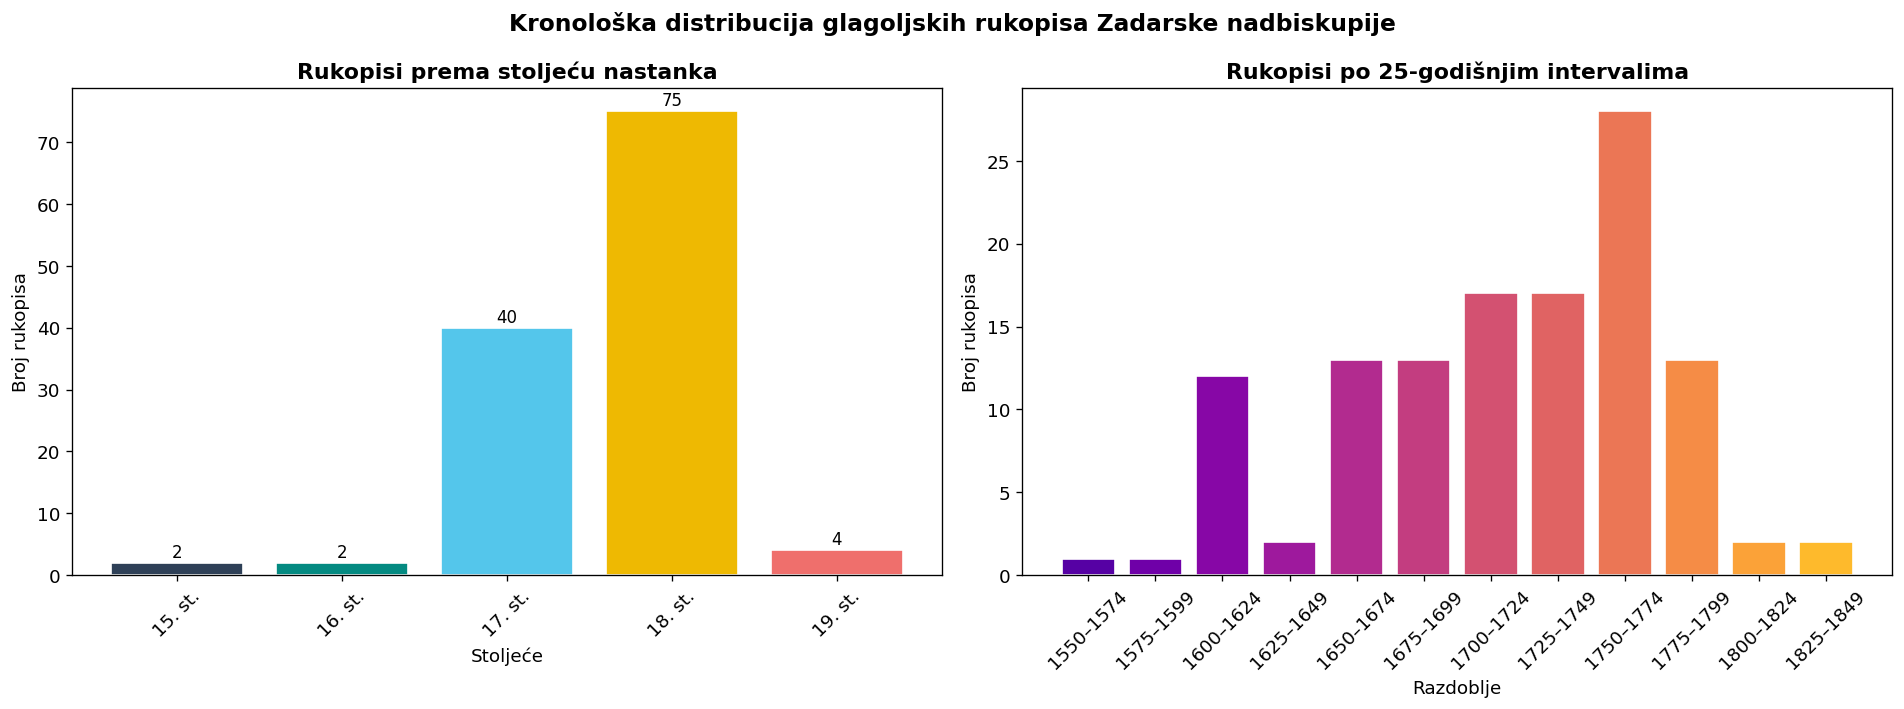

Pohranjeno: slike/glag_kronologija.png


In [5]:
# ── VIZUALIZACIJA 1: Kronološka distribucija ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Kronološka distribucija glagoljskih rukopisa Zadarske nadbiskupije',
             fontsize=14, fontweight='bold')

# 1a – Početak po stoljeću
century_counts = df['stoljece_pocetka'].dropna().value_counts()
century_order = sorted(century_counts.index, key=lambda x: int(re.search(r'\d+', x).group()))
cs = century_counts.reindex(century_order)
bars = axes[0].bar(cs.index, cs.values, color=PALETTE[:len(cs)], edgecolor='white')
axes[0].set_title('Rukopisi prema stoljeću nastanka', fontweight='bold')
axes[0].set_xlabel('Stoljeće')
axes[0].set_ylabel('Broj rukopisa')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, cs.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(v), ha='center', va='bottom', fontsize=10)

# 1b – Distribucija po 25-godišnjim intervalima
df_y = df.dropna(subset=['godina_pocetka'])
df_y = df_y[(df_y['godina_pocetka'] >= 1500) & (df_y['godina_pocetka'] <= 1900)]
df_y['period'] = (df_y['godina_pocetka'] // 25) * 25
pc = df_y.groupby('period').size()
colors_t = plt.cm.plasma(np.linspace(0.15, 0.85, len(pc)))
axes[1].bar([f'{int(y)}–{int(y)+24}' for y in pc.index], pc.values,
            color=colors_t, edgecolor='white')
axes[1].set_title('Rukopisi po 25-godišnjim intervalima', fontweight='bold')
axes[1].set_xlabel('Razdoblje')
axes[1].set_ylabel('Broj rukopisa')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('slike/glag_kronologija.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_kronologija.png')

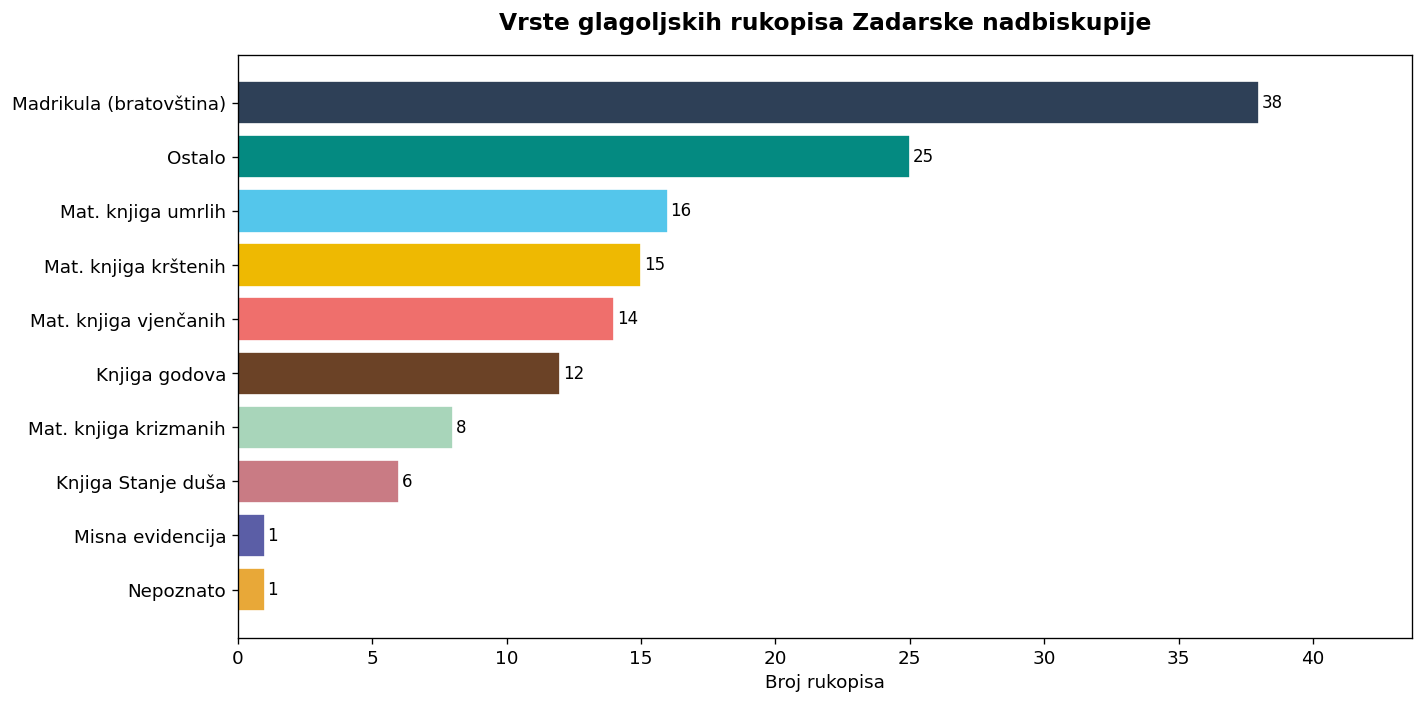

Pohranjeno: slike/glag_vrste_dokumenata.png


In [6]:
# ── VIZUALIZACIJA 2: Vrste dokumenata ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
kat = df['kategorija'].value_counts().sort_values()
colors = PALETTE[:len(kat)]
bars = ax.barh(kat.index, kat.values, color=colors[::-1], edgecolor='white')
ax.set_title('Vrste glagoljskih rukopisa Zadarske nadbiskupije',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Broj rukopisa')
for bar, v in zip(bars, kat.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=10)
ax.set_xlim(0, kat.max() * 1.15)
plt.tight_layout()
plt.savefig('slike/glag_vrste_dokumenata.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_vrste_dokumenata.png')

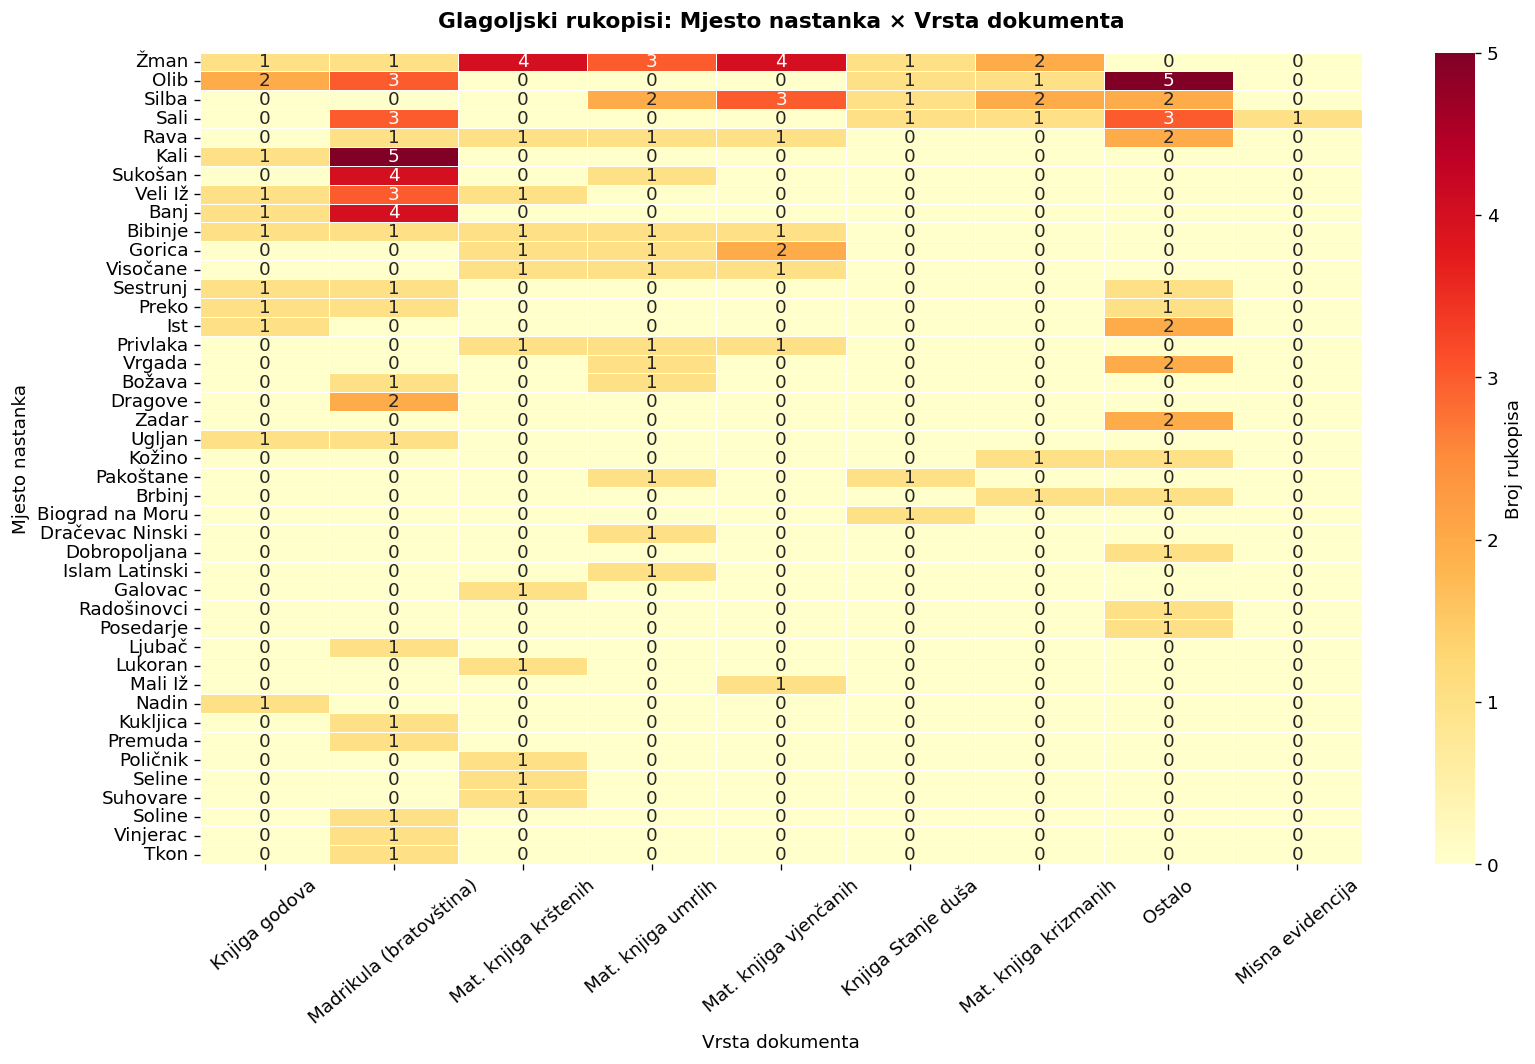

Pohranjeno: slike/glag_heatmapa.png


In [7]:
# ── VIZUALIZACIJA 3: Heatmapa – mjesto × vrsta dokumenta ────────────────────
pivot = (df.groupby(['mjesto_izdavanja_proizvodnje', 'kategorija'])
           .size().unstack(fill_value=0))
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Broj rukopisa'}, ax=ax)
ax.set_title('Glagoljski rukopisi: Mjesto nastanka × Vrsta dokumenta',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Vrsta dokumenta')
ax.set_ylabel('Mjesto nastanka')
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('slike/glag_heatmapa.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_heatmapa.png')

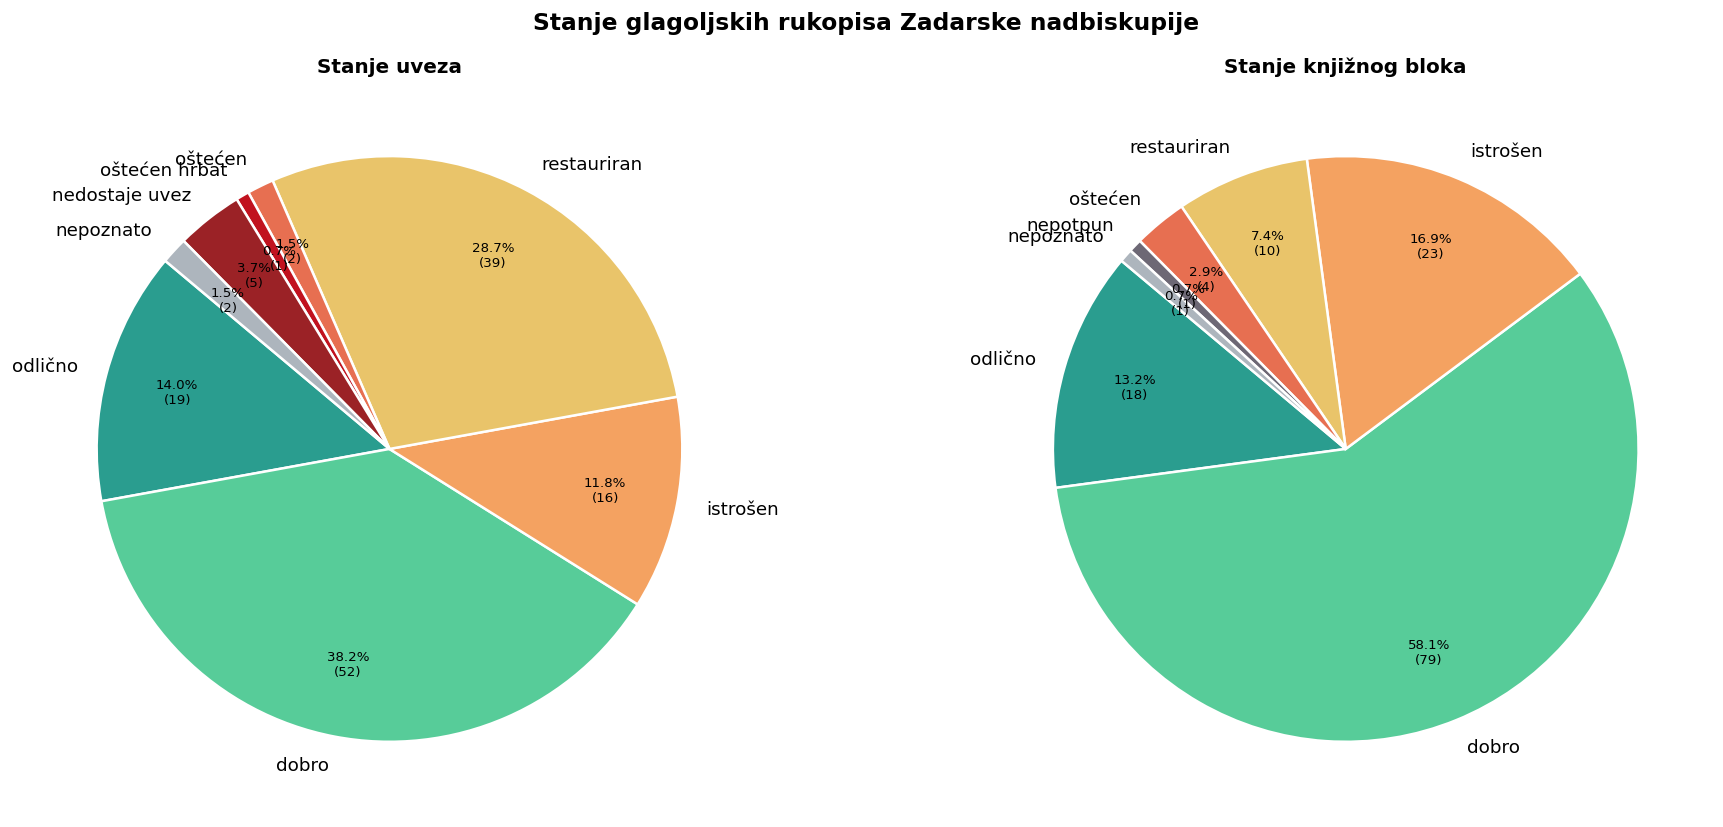

Pohranjeno: slike/glag_stanje.png


In [8]:
# ── VIZUALIZACIJA 4: Stanje rukopisa ────────────────────────────────────────
CONDITION_ORDER = ['odlično', 'dobro', 'istrošen', 'restauriran',
                   'oštećen', 'oštećen hrbat', 'nedostaje uvez',
                   'nepotpun', 'nepoznato']
CONDITION_COLORS = ['#2a9d8f','#57cc99','#f4a261','#e9c46a',
                    '#e76f51','#c1121f','#9b2226','#6d6875','#adb5bd']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Stanje glagoljskih rukopisa Zadarske nadbiskupije',
             fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['stanje_uveza', 'stanje_bloka'],
    ['Stanje uveza', 'Stanje knjižnog bloka']
):
    counts = df[col].value_counts()
    present = [c for c in CONDITION_ORDER if c in counts.index]
    vals = [counts[c] for c in present]
    cols = [CONDITION_COLORS[CONDITION_ORDER.index(c)] for c in present]
    wedges, texts, autotexts = ax.pie(
        vals, labels=present, colors=cols,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p*sum(vals)/100))})',
        startangle=140, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for t in autotexts: t.set_fontsize(8)
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('slike/glag_stanje.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_stanje.png')

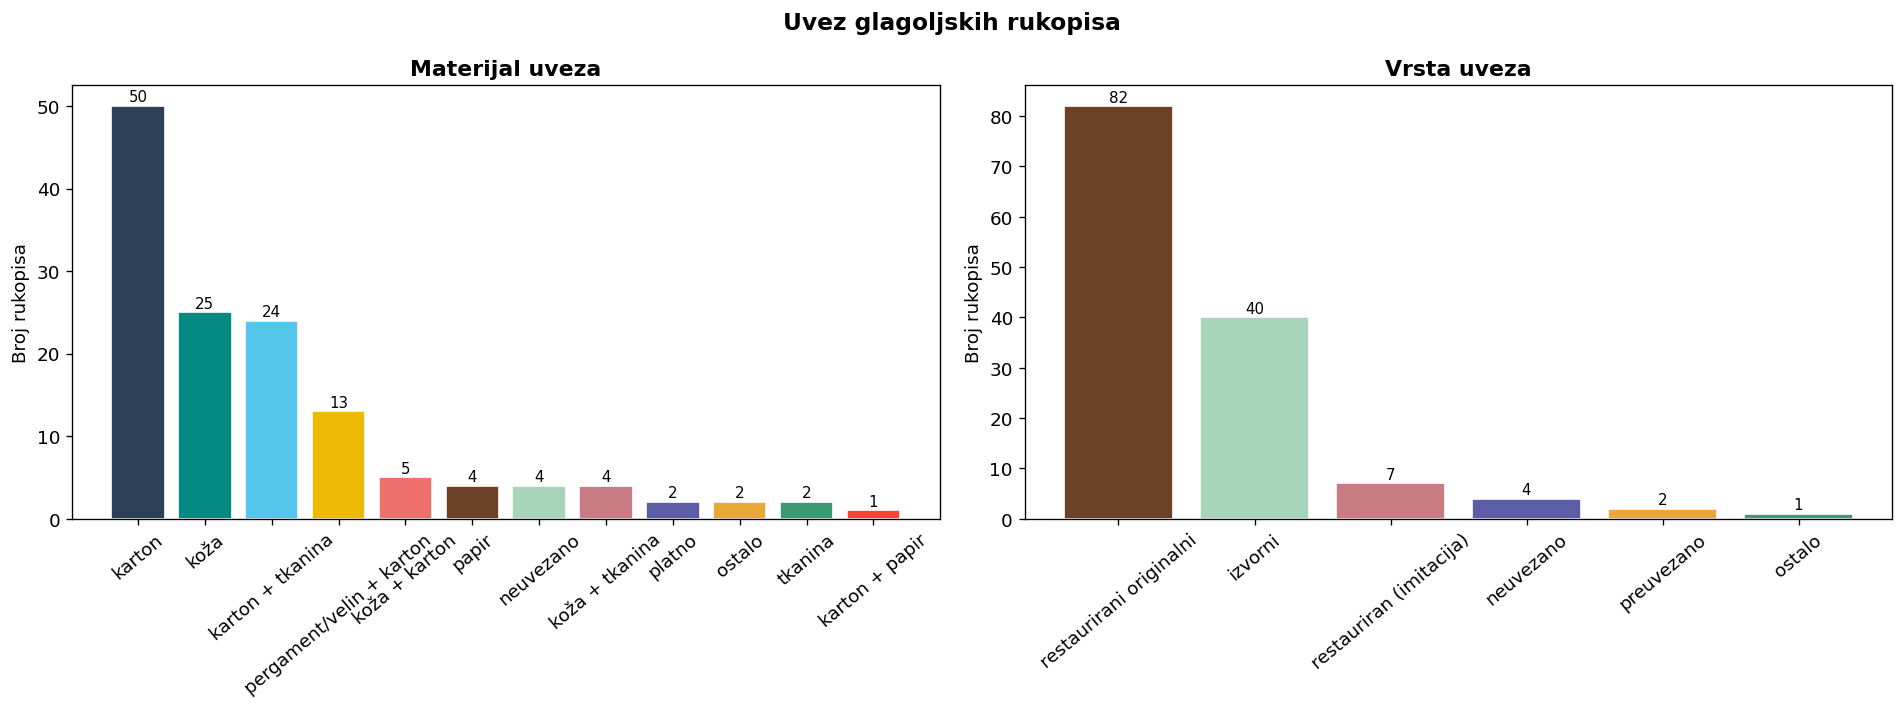

Pohranjeno: slike/glag_uvez.png


In [9]:
# ── VIZUALIZACIJA 5: Materijal i vrsta uveza ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Uvez glagoljskih rukopisa', fontsize=14, fontweight='bold')

# 5a – Materijal uveza
mat_counts = df['materijal_uveza_norm'].value_counts()
axes[0].bar(mat_counts.index, mat_counts.values,
            color=PALETTE[:len(mat_counts)], edgecolor='white')
axes[0].set_title('Materijal uveza', fontweight='bold')
axes[0].set_ylabel('Broj rukopisa')
axes[0].tick_params(axis='x', rotation=40)
for i, v in enumerate(mat_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=9)

# 5b – Vrsta uveza
vr_counts = df['vrsta_uveza_norm'].value_counts()
axes[1].bar(vr_counts.index, vr_counts.values,
            color=PALETTE[5:5+len(vr_counts)], edgecolor='white')
axes[1].set_title('Vrsta uveza', fontweight='bold')
axes[1].set_ylabel('Broj rukopisa')
axes[1].tick_params(axis='x', rotation=40)
for i, v in enumerate(vr_counts.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('slike/glag_uvez.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_uvez.png')

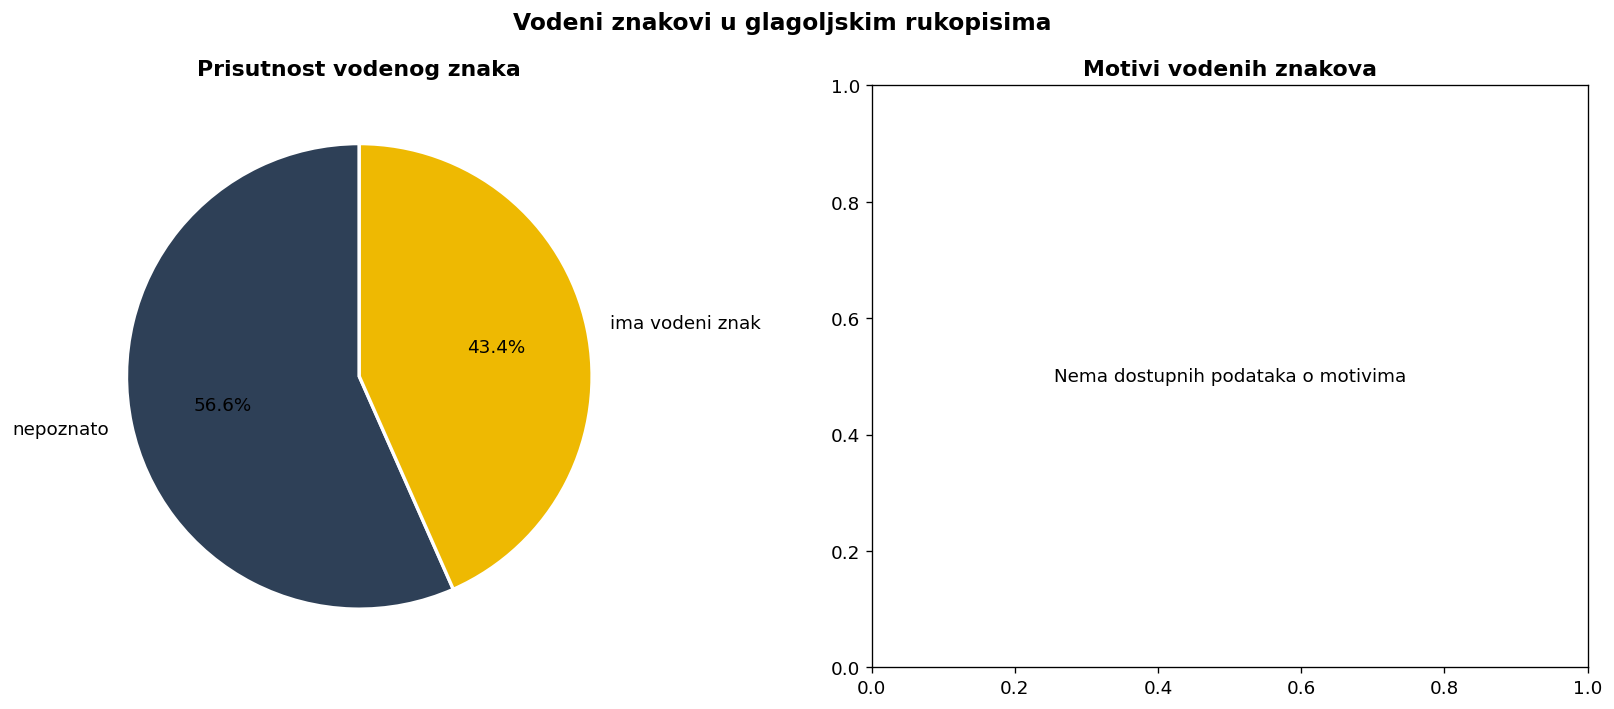

Pohranjeno: slike/glag_vodeni_znakovi.png


In [10]:
# ── VIZUALIZACIJA 6: Vodeni znakovi ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Vodeni znakovi u glagoljskim rukopisima', fontsize=14, fontweight='bold')

# 6a – Prisutnost vodenog znaka
wm_counts = df['vodeni_znak_norm'].value_counts()
colors_wm = ['#2E4057', '#EEB902', '#adb5bd'][:len(wm_counts)]
axes[0].pie(wm_counts.values, labels=wm_counts.index,
            colors=colors_wm, autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Prisutnost vodenog znaka', fontweight='bold')

# 6b – Top motivi vodenih znakova
wm_motifs = (df['vodeni_znak'].dropna()
             .str.split(';').explode()
             .str.strip()
             .value_counts()
             .head(12))
# Remove coded entries
wm_motifs = wm_motifs[~wm_motifs.index.str.startswith('0') &
                       ~wm_motifs.index.str.startswith('1')]
if len(wm_motifs) > 0:
    axes[1].barh(wm_motifs.index[::-1], wm_motifs.values[::-1],
                 color='#048A81', edgecolor='white')
    axes[1].set_title('Najčešći motivi vodenih znakova', fontweight='bold')
    axes[1].set_xlabel('Broj rukopisa')
else:
    axes[1].text(0.5, 0.5, 'Nema dostupnih podataka o motivima',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Motivi vodenih znakova', fontweight='bold')

plt.tight_layout()
plt.savefig('slike/glag_vodeni_znakovi.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_vodeni_znakovi.png')

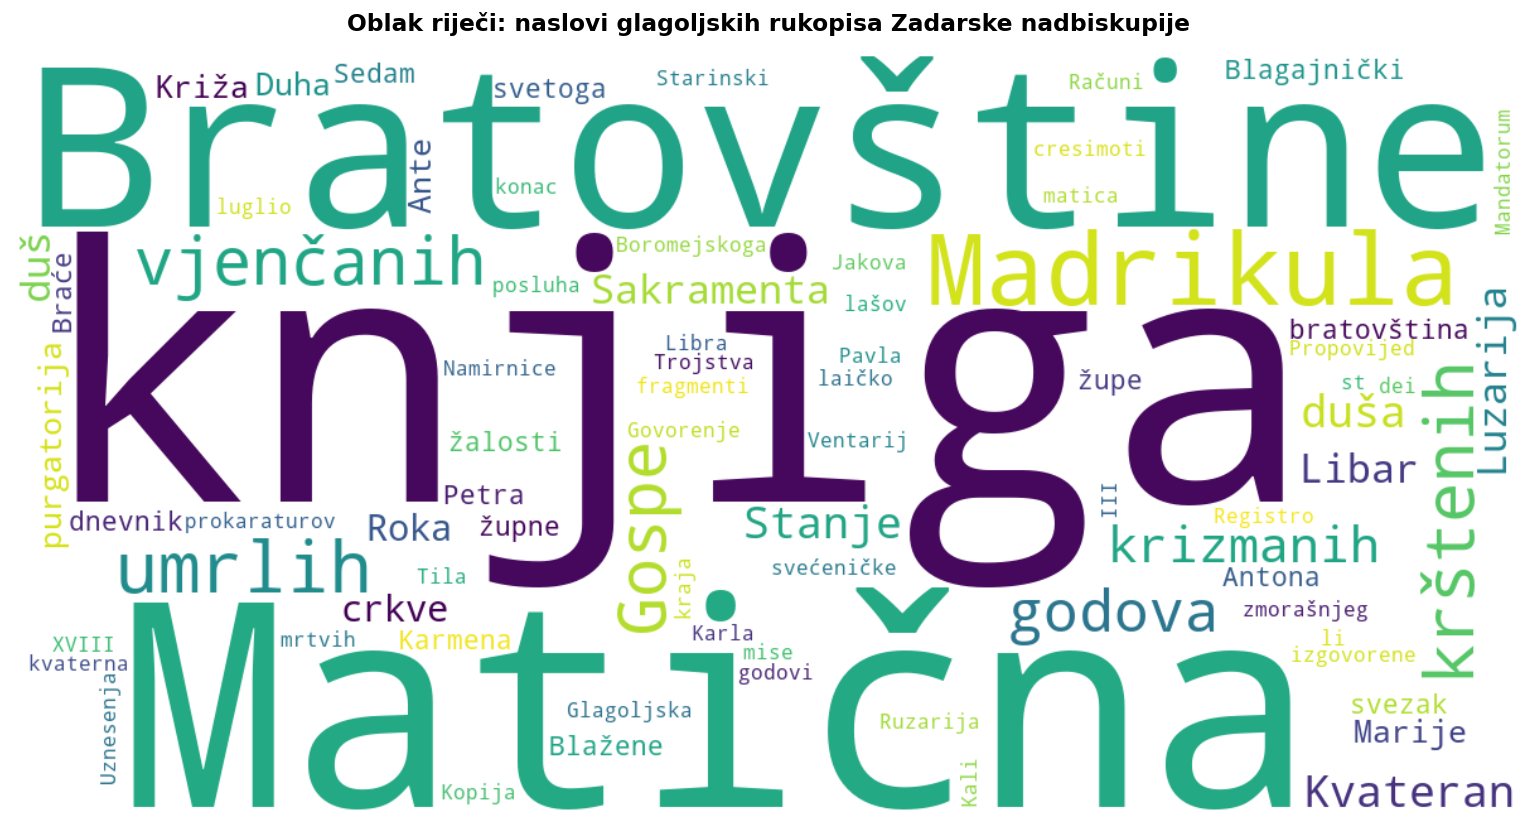

Pohranjeno: slike/glag_wordcloud.png


In [11]:
# ── VIZUALIZACIJA 7: Oblak riječi naslova ────────────────────────────────────
all_titles = ' '.join(df['naslov'].dropna().tolist())

# Ukloni česte funkcijske riječi
stopwords_hr = {'od', 'i', 'u', 'na', 'za', 'je', 'su', 'se', 'da',
                'do', 'te', 'ili', 'iz', 'po', 'sa', 'o', 'a', 'the',
                'svetog', 'svete', 'sveti', 'svetih'}

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    stopwords=stopwords_hr,
    max_words=80,
    prefer_horizontal=0.85,
    font_path=None,
    collocations=False
).generate(all_titles)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Oblak riječi: naslovi glagoljskih rukopisa Zadarske nadbiskupije',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('slike/glag_wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()
print('Pohranjeno: slike/glag_wordcloud.png')

### Interaktivne vizualizacije


In [12]:
# ── VIZUALIZACIJA 8: Interaktivna karta – Folium ─────────────────────────────
PLACE_COORDS = {
    'Žman':       (43.9769, 15.2061),
    'Olib':       (44.3758, 14.7842),
    'Silba':      (44.3719, 14.6903),
    'Sali':       (43.9347, 15.1556),
    'Kali':       (44.0628, 15.2122),
    'Rava':       (43.9653, 15.0608),
    'Veli Iž':    (44.0514, 15.1183),
    'Mali Iž':    (44.0544, 15.1050),
    'Sukošan':    (44.0319, 15.3269),
    'Bibinje':    (44.0628, 15.2878),
    'Gorica':     (44.1580, 15.3530),
    'Privlaka':   (44.2344, 15.1481),
    'Preko':      (44.0789, 15.2014),
    'Ist':        (44.2717, 14.7647),
    'Vrgada':     (43.8525, 15.4833),
    'Visočane':   (44.1003, 15.4219),
    'Sestrunj':   (44.1417, 15.0458),
    'Zadar':      (44.1194, 15.2422),
    'Ugljan':     (44.0939, 15.2019),
    'Pakoštane':  (43.9100, 15.5097),
    'Banj':       (43.9480, 15.4050),
    'Ždrelac':    (44.0400, 15.1800),
    'Lukoran':    (44.1011, 15.2203),
    'Tkon':       (43.9260, 15.4040),
    'Murter':     (43.8103, 15.5994),
    'Biograd':    (43.9381, 15.4456),
    'Nin':        (44.2411, 15.1775),
    'Diklo':      (44.1575, 15.2631),
    'Petrčane':   (44.1911, 15.2094),
    'Turanj':     (43.9517, 15.4667),
}

# Grupiranje po mjestu
place_groups = {}
for _, row in df.iterrows():
    place = str(row.get('mjesto_izdavanja_proizvodnje', '') or '').strip()
    if not place or place == 'nan': continue
    coords = PLACE_COORDS.get(place)
    if not coords: continue
    if place not in place_groups:
        place_groups[place] = []
    place_groups[place].append(row)

# Kategorija → boja
KAT_COLORS = {
    'Mat. knjiga krštenih':    '#e63946',
    'Mat. knjiga vjenčanih':   '#2a9d8f',
    'Mat. knjiga umrlih':      '#264653',
    'Mat. knjiga krizmanih':   '#e9c46a',
    'Knjiga godova':           '#f4a261',
    'Knjiga Stanje duša':      '#a8dadc',
    'Madrikula (bratovština)': '#6d4c41',
    'Misna evidencija':        '#b5838d',
    'Ostalo':                  '#adb5bd',
}

m = folium.Map(location=[44.05, 15.15], zoom_start=10,
               tiles='CartoDB positron')

for place, rows in place_groups.items():
    coords = PLACE_COORDS[place]
    count = len(rows)
    radius = 8 + count * 1.8

    # Tablica za popup
    kat_dist = Counter(r['kategorija'] for r in rows)
    table_rows = ''.join(
        f'<tr><td style="padding:2px 8px;">{k}</td>'
        f'<td style="padding:2px 8px; text-align:center;">{v}</td></tr>'
        for k, v in sorted(kat_dist.items(), key=lambda x: -x[1])
    )
    popup_html = (
        f'<div style="font-family:sans-serif; min-width:220px;">'
        f'<b style="font-size:14px;">{place}</b><br>'
        f'<span style="color:#666;">{count} rukopis{"a" if count != 1 else ""}</span>'
        f'<hr style="margin:6px 0;">'
        f'<table style="width:100%; font-size:12px;">'
        f'<tr><th style="text-align:left;">Vrsta</th><th>Broj</th></tr>'
        f'{table_rows}</table>'
        f'<hr style="margin:6px 0;">'
        f'<details><summary style="cursor:pointer; font-size:11px; color:#048A81;">'
        f'Prikaži naslov / signaturu</summary>'
        + ''.join(
            f'<div style="font-size:10px; margin:2px 0; color:#333;">'
            f'<b>{r["naslov"]}</b> — {r.get("raspon_godina_izdavanja_proizvodnje","?")}'
            f' [{r.get("signatura","?")}]</div>'
            for r in rows
        )
        + '</details></div>'
    )
    folium.CircleMarker(
        location=coords,
        radius=radius,
        color='white', weight=1.5,
        fill=True, fill_color='#2E4057', fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f'{place}: {count} rukopisa'
    ).add_to(m)

# Legenda
legend_html = '<div style="position:fixed; bottom:30px; left:30px; z-index:1000; background:white; padding:12px; border-radius:8px; border:1px solid #ddd; font-family:sans-serif; font-size:12px;"><b>Mjesta nastanka rukopisa</b><br><span style="color:#666;">Veličina kruga = broj rukopisa</span></div>'
m.get_root().html.add_child(folium.Element(legend_html))

m.save('slike/glag_karta.html')
display(HTML('<a href="slike/glag_karta.html" target="_blank">Otvori interaktivnu kartu</a>'))
display(m)
print('Pohranjeno: slike/glag_karta.html')

Pohranjeno: slike/glag_karta.html


In [13]:
# ── VIZUALIZACIJA 9: Interaktivni Altair – Vrste dokumenata po mjestu ─────────
# Pripremi podatke
df_alt = (df.groupby(['mjesto_izdavanja_proizvodnje', 'kategorija'])
            .size().reset_index(name='broj'))
df_alt.columns = ['mjesto', 'kategorija', 'broj']

# Sortiraj mjesta po ukupnom broju
mjesta_order = (df_alt.groupby('mjesto')['broj'].sum()
                .sort_values(ascending=False).index.tolist())

selection = alt.selection_point(fields=['kategorija'], bind='legend')

chart = (
    alt.Chart(df_alt)
    .mark_bar()
    .encode(
        x=alt.X('broj:Q', title='Broj rukopisa'),
        y=alt.Y('mjesto:N', sort=mjesta_order, title='Mjesto nastanka'),
        color=alt.Color('kategorija:N',
                        title='Vrsta dokumenta',
                        scale=alt.Scale(scheme='tableau10')),
        opacity=alt.condition(selection, alt.value(1), alt.value(0.15)),
        tooltip=[
            alt.Tooltip('mjesto:N', title='Mjesto'),
            alt.Tooltip('kategorija:N', title='Vrsta'),
            alt.Tooltip('broj:Q', title='Broj rukopisa'),
        ]
    )
    .add_params(selection)
    .properties(
        width=550, height=480,
        title='Glagoljski rukopisi: Vrste dokumenata po mjestima nastanka'
    )
)

chart.save('slike/glag_vrste_po_mjestima.html')
display(chart)
print('Pohranjeno: slike/glag_vrste_po_mjestima.html')

alt.Chart(...)

Pohranjeno: slike/glag_vrste_po_mjestima.html


In [14]:
# ── VIZUALIZACIJA 10: Interaktivni Altair – Vremenska crta po kategoriji ──────
df_tl = df.dropna(subset=['godina_pocetka']).copy()
df_tl['godina_kraja_fill'] = df_tl['godina_kraja'].fillna(df_tl['godina_pocetka'] + 50)
df_tl = df_tl[df_tl['godina_pocetka'] >= 1500]

selection_k = alt.selection_point(fields=['kategorija'], bind='legend')

strip = (
    alt.Chart(df_tl)
    .mark_rule(strokeWidth=3, opacity=0.75)
    .encode(
        x=alt.X('godina_pocetka:Q', title='Godina', scale=alt.Scale(domain=[1580, 1920])),
        x2='godina_kraja_fill:Q',
        y=alt.Y('kategorija:N', title='Vrsta dokumenta', sort='-x'),
        color=alt.Color('kategorija:N',
                        scale=alt.Scale(scheme='tableau10'),
                        legend=alt.Legend(title='Vrsta dokumenta')),
        opacity=alt.condition(selection_k, alt.value(0.85), alt.value(0.1)),
        tooltip=[
            alt.Tooltip('naslov:N', title='Naslov'),
            alt.Tooltip('mjesto_izdavanja_proizvodnje:N', title='Mjesto'),
            alt.Tooltip('raspon_godina_izdavanja_proizvodnje:N', title='Datacija'),
            alt.Tooltip('signatura:N', title='Signatura'),
        ]
    )
    .add_params(selection_k)
    .properties(
        width=700, height=350,
        title='Vremenska crta glagoljskih rukopisa Zadarske nadbiskupije'
    )
)

strip.save('slike/glag_vremenska_crta.html')
display(strip)
print('Pohranjeno: slike/glag_vremenska_crta.html')

alt.Chart(...)

Pohranjeno: slike/glag_vremenska_crta.html


In [15]:
# ── VIZUALIZACIJA 11: Heatmapa gustoće – karta (Folium HeatMap) ───────────────
m_heat = folium.Map(location=[44.05, 15.15], zoom_start=10,
                    tiles='CartoDB dark_matter')

heat_data = []
for _, row in df.iterrows():
    place = str(row.get('mjesto_izdavanja_proizvodnje', '') or '').strip()
    coords = PLACE_COORDS.get(place)
    if coords:
        heat_data.append([coords[0], coords[1], 1])

HeatMap(heat_data, radius=25, blur=20, min_opacity=0.3).add_to(m_heat)

m_heat.save('slike/glag_karta_heatmap.html')
display(HTML('<a href="slike/glag_karta_heatmap.html" target="_blank">Otvori heatmapu gustoće</a>'))
print('Pohranjeno: slike/glag_karta_heatmap.html')

Pohranjeno: slike/glag_karta_heatmap.html


In [16]:
# ── Sažetak ───────────────────────────────────────────────────────────────────
print('=' * 60)
print('SAŽETAK: Glagoljski rukopisi Zadarske nadbiskupije')
print('=' * 60)
print(f'Ukupno rukopisa:   {len(df)}')
print(f'Mjesta nastanka:   {df["mjesto_izdavanja_proizvodnje"].nunique()}')
print(f'Kategorije:        {df["kategorija"].nunique()}')
print()
print('Generirana vizualizacije:')
import os
for f in sorted(os.listdir('slike')):
    if f.startswith('glag_'):
        print(f'  ✓ slike/{f}')

SAŽETAK: Glagoljski rukopisi Zadarske nadbiskupije
Ukupno rukopisa:   136
Mjesta nastanka:   43
Kategorije:        10

Generirana vizualizacije:
  ✓ slike/glag_heatmapa.png
  ✓ slike/glag_karta.html
  ✓ slike/glag_karta_heatmap.html
  ✓ slike/glag_kronologija.png
  ✓ slike/glag_stanje.png
  ✓ slike/glag_uvez.png
  ✓ slike/glag_vodeni_znakovi.png
  ✓ slike/glag_vremenska_crta.html
  ✓ slike/glag_vrste_dokumenata.png
  ✓ slike/glag_vrste_po_mjestima.html
  ✓ slike/glag_wordcloud.png
